<a href="https://colab.research.google.com/github/s32ol/predictive-maintenance-ai4i/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: EDA Verification

This notebook reproduces and verifies the Phase 1 EDA findings from the project README against live data, then translates each finding into both technical and business-facing language.

Dataset: AI4I 2020 Predictive Maintenance (Matzka, 2020) — 10,000 rows of synthetic CNC milling telemetry with a binary failure label.

Goal: build a classifier that flags machines at risk of failure from sensor readings, while remaining honest about a 28:1 class imbalance.

Structure of each finding below:

- What we measured (the code result)

- Technical interpretation — for data-science reviewers

- Business interpretation — for non-technical stakeholders

- Decisions this drives in Phase 2 — modeling implications

Every modeling choice in Phase 2 traces back to one of these four findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Library versions
print(f"pandas {pd.__version__}")
print(f"numpy {np.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print(f"seaborn {sns.__version__}")

pandas 2.2.2
numpy 2.0.2
matplotlib 3.10.0
seaborn 0.13.2


In [2]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.shape

(10000, 14)

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## Setup & sanity checks

Data loaded directly from the UCI ML Repository (the original source — Kaggle hosts a mirror).

Sanity check results:

- 10,000 rows × 14 columns ✓

- No null values in any column ✓

- Dtypes correct: sensors numeric, Type and Product ID as strings, binary flags as int ✓

- Memory footprint ~1.1 MB

Translation for stakeholders: the data is small, clean, and complete. No data-quality issues at the structural level. Ready for analysis.

**Class balance check** — what fraction of rows are failures?

In [5]:
print(df['Machine failure'].value_counts())
print()
print(df['Machine failure'].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


## Finding 1: Class imbalance — 28:1

### Technical interpretation

The dataset is heavily imbalanced: 9,661 non-failures (96.61%) and 339 failures (3.39%) — a 28.5:1 negative-to-positive ratio. This rules out accuracy as a meaningful metric; a trivial model that predicts "no failure" for every row would score 96.6% accurate and have zero business value. Imbalance also drives the choice of split strategy (stratified), evaluation metric (PR-AUC over ROC-AUC), and training procedure (class weighting).

### Business interpretation

Roughly 1 in 30 machines fails. This is a needle-in-haystack detection problem, not a balanced classification problem. A model that says "everything's fine" all the time would be technically right 97% of the time — but never catch a failure, which defeats the purpose.

### Decisions this drives in Phase 2

- Stratified splits — every train/test/CV fold preserves the 3.4% failure rate so each fold has enough positives to learn from

- PR-AUC as the primary metric — not accuracy, not even ROC-AUC (which inflates with imbalance because the negative class dominates the FPR denominator)

- Class weighting during training — class_weight='balanced' for logistic regression, scale_pos_weight=~28 for XGBoost

- Threshold tuning — the default 0.5 is too strict for rare classes; we tune toward higher recall, since missed failures cost ~10× more than false alarms in a maintenance context

**Sensor correlation matrix** — how do the five sensor channels relate to each other?

In [6]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[sensor_cols].corr().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.00,0.88,0.02,-0.01,0.01
Process temperature [K],0.88,1.00,0.02,-0.01,0.01
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00
Tool wear [min],0.01,0.01,0.00,-0.00,1.00


### Visualizing the correlation matrix

Same numerical data as the table above, rendered as a heatmap so the strong correlations jump out at a glance.

**What to look for:**
- Two **deeply colored off-diagonal cells** — one positive (red), one negative (blue) — at the (Air temp, Process temp) and (Rotational speed, Torque) positions. These are the +0.88 and −0.88 correlations.
- The **diagonal is all 1.00** by construction (every variable correlates perfectly with itself) — ignore it.
- **Everything else is near-white**, confirming those sensor pairs are essentially uncorrelated. Tool wear's row and column are near-zero across the board, which means it's independent of every other sensor — useful unique signal.

The physics explanation and feature engineering decisions that flow from these correlations are in **Finding 2** below.

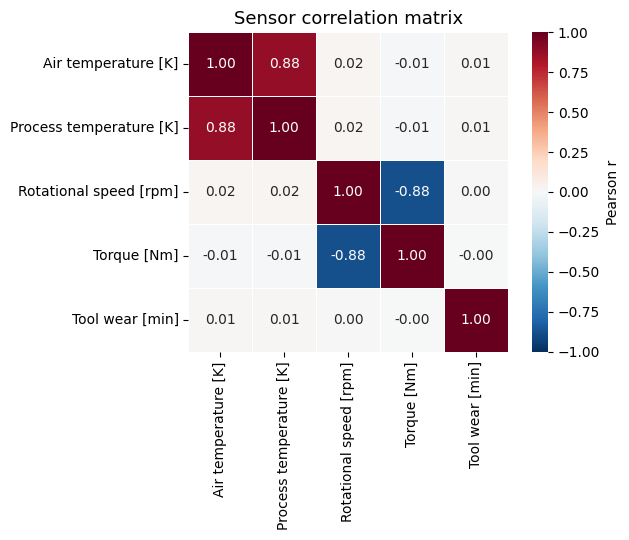

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Sensor correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Finding 2: Multicollinearity — physics-driven correlations

### Technical interpretation

Two strong correlations among the five sensor channels:

- Air temperature ↔ Process temperature: +0.88 — process temperature is constructed additively from air temperature (per dataset spec: process_temp ≈ air_temp + 10K + noise).

- Rotational speed ↔ Torque: −0.88 — at the machine's roughly constant ~2,860 W operating power, torque and rpm trade off mechanically (Power = Torque × ω).

All other correlations are essentially zero. Tool wear is independent of every other sensor, which means it carries unique information not captured anywhere else — it accumulates monotonically with time, regardless of operating conditions.

### Business interpretation

Two pairs of sensors are mechanically linked:

- Room temp and cutting temp move together — when the workshop gets hot, the cutting gets hot.

- Spindle speed and torque are inversely linked — same as a vehicle transmission. Low gear = high torque + low speed; high gear = low torque + high speed.

Tool wear is its own story — it accumulates over time regardless of operating conditions, so it carries unique signal.

### Decisions this drives in Phase 2

We don't drop a feature from each correlated pair (that loses information). Instead, we engineer the underlying physical quantities directly:

- **temp_diff** = `process_temp − air_temp` — isolates heat generated by the cutting operation, separated from ambient. This is the variable that should drive heat dissipation failures (per the dataset spec, HDF triggers when this gap drops below 8.6 K).

- **power_proxy** = `torque × rotational_speed` — the actual power being drawn. Per the dataset spec, power failures (PWF) trigger below 3,500 W or above 9,000 W.

These engineered features are derived from physics, not statistics — they map directly to the documented failure-mode triggers.

**Failure rate by Type** — does product grade carry signal?

In [8]:
df.groupby('Type')['Machine failure'].mean()

,Machine failure
Type,
H,0.020937
L,0.039167
M,0.027694


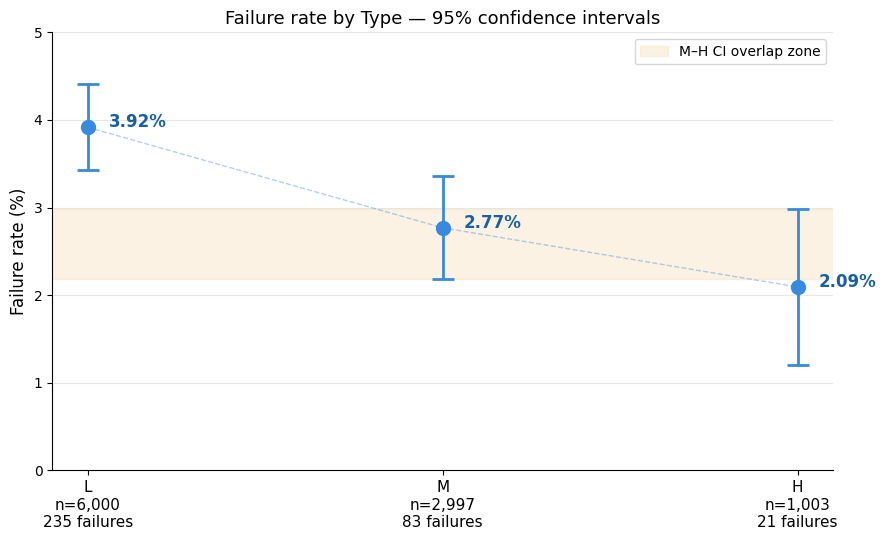

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Compute rates, sample sizes, and failure counts
stats = df.groupby('Type')['Machine failure'].agg(['mean', 'count', 'sum'])
stats = stats.reindex(['L', 'M', 'H'])  # enforce L → M → H order

p = stats['mean'].values
n = stats['count'].values
failures = stats['sum'].values
ci_95 = 1.96 * np.sqrt(p * (1 - p) / n)  # 95% CI half-width

# Build the chart
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)
types = ['L', 'M', 'H']

# Points with error bars
ax.errorbar(x, p * 100, yerr=ci_95 * 100, fmt='o',
            color='#378ADD', ecolor='#378ADD',
            capsize=8, capthick=2, markersize=10, linewidth=2)

# Dashed trend line
ax.plot(x, p * 100, '--', color='#378ADD', alpha=0.4, linewidth=1)

# Rate labels next to each point
for i in range(3):
    ax.annotate(f'{p[i]*100:.2f}%', (x[i], p[i] * 100),
                xytext=(15, 0), textcoords='offset points',
                fontsize=12, color='#185FA5', fontweight='bold')

# M-H CI overlap zone (the noisy region)
m_low, m_high = (p[1] - ci_95[1]) * 100, (p[1] + ci_95[1]) * 100
h_low, h_high = (p[2] - ci_95[2]) * 100, (p[2] + ci_95[2]) * 100
overlap_low = max(m_low, h_low)
overlap_high = min(m_high, h_high)
if overlap_high > overlap_low:
    ax.axhspan(overlap_low, overlap_high, alpha=0.13, color='#EF9F27',
               label='M–H CI overlap zone')

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\nn={n[i]:,}\n{failures[i]} failures"
                    for i, t in enumerate(types)], fontsize=11)
ax.set_ylabel('Failure rate (%)', fontsize=12)
ax.set_title('Failure rate by Type — 95% confidence intervals', fontsize=13)
ax.set_ylim(0, 5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Finding 3: Failure rate by Type — monotonic, with noisy edges

### Technical interpretation

Failure rate by product Type forms a monotonic descent:

| Type | n | Failures | Rate | 95% CI |
|------|---|----------|------|--------|
| L | 6,000 | 235 | 3.92% | [3.4%, 4.4%] |
| M | 3,000 | 83 | 2.77% | [2.2%, 3.4%] |
| H | 1,000 | 21 | 2.09% | [1.2%, 3.0%] |

Statistical reading:

- The L-vs-rest gap is robust (CIs don't overlap with M or H).

- The M-vs-H gap is borderline — CIs overlap from 2.2% to 3.0%, so they could plausibly share the same true rate.

- The monotonic trend itself is evidence of an ordered underlying cause — three points in the right order, consistent with the physics, is harder to explain by chance than any single pairwise comparison being significant.

Doc-vs-data discrepancy: the actual Type distribution is L 60% / M 30% / H 10%, not the 50/30/20 the dataset description claims. The data is the ground truth.

### Business interpretation

Lower-grade parts fail meaningfully more often than higher-grade parts. About 4% of L-grade machining jobs fail, vs about 2% for H-grade. M (medium) sits between them. This makes physical sense — cheaper, more variable raw stock stresses the cutting tool more, leading to more failures.

We have strong evidence for the L-vs-rest gap. The middle (M vs H) is fuzzier because we only have ~21 H-grade failures in the entire dataset, so the H rate has wide statistical uncertainty.

### Decisions this drives in Phase 2

- Keep Type as a feature — it carries real signal

- One-hot encode it (L/M/H → binary indicator columns)

- Stratify splits on Type — with only 21 H-grade failures, we can't afford to lose them all to one fold

In [10]:
# Check: does Machine failure equal the OR of the 5 mode flags, row by row?
mode_or = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].any(axis=1).astype(int)

exact_match = (mode_or == df['Machine failure']).all()
print(f"Perfect match across all 10,000 rows? {exact_match}")

if not exact_match:
    mismatches = df[mode_or != df['Machine failure']]
    print(f"\nMismatching rows: {len(mismatches)} out of {len(df)} "
          f"({len(mismatches)/len(df)*100:.3f}%)")
    print("\nThe mismatches:")
    print(mismatches[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']])

Perfect match across all 10,000 rows? False

Mismatching rows: 27 out of 10000 (0.270%)

The mismatches:
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0    0    0    0    0    1
2559                0    0    0    0    0    1
2749                1    0    0    0    0    0
3065                0    0    0    0    0    1
3452                0    0    0    0    0    1
4044                1    0    0    0    0    0
4684                1    0    0    0    0    0
5471                0    0    0    0    0    1
5489                0    0    0    0    0    1
5495                0    0    0    0    0    1
5509                0    0    0    0    0    1
5536                1    0    0    0    0    0
5553                0    0    0    0    0    1
5639                0    0    0    0    0    1
59

## Finding 4: Target leakage — TWF / HDF / PWF / OSF / RNF must be dropped

### Technical interpretation

The five "failure mode" columns are not features but components of the target label. Per the dataset spec, the relationship is:

```
Machine failure = TWF OR HDF OR PWF OR OSF OR RNF
```

Verification on the actual data: the relationship holds for 99.73% of rows (9,973 / 10,000) with 27 anomalies in two distinct patterns:

- 18 rows where RNF=1 but Machine failure=0 (random-failure flag didn't propagate to the label)

- 9 rows where Machine failure=1 but all five mode flags=0 (failure with no labeled cause)

Negligible noise at 0.27%, but a real doc-vs-data discrepancy worth surfacing.

0.27% of rows but ~8% of the failure population — for an imbalanced problem, label noise concentrating in the rare class is the real concern. Doesn't change the modeling plan, but sets an irreducible-error expectation for Phase 2 evaluation.

These five columns are textbook target leakage — they're computed from the failure event, not before it. Training with them would produce a model scoring ~99.7% on validation (because it's reading off the answer key) and useless in production (because at inference time, the failure hasn't happened yet, so these columns don't exist).

### Business interpretation

The five failure-type columns aren't sensor readings — they're labels describing which kind of failure happened. They only exist after a failure occurs. If we trained the model with them, we'd be handing it the answer. The model would look brilliant in testing and crash the moment we deployed it.

Analogy: predicting whether a bearing will fail using the post-failure inspection report as a feature. The inspection report is gold — but it only exists after the bearing has failed. Useless for prediction.

### Decisions this drives in Phase 2

- Drop TWF, HDF, PWF, OSF, RNF before any modeling code runs — non-negotiable

- Also drop UDI (unique row identifier, no predictive value) and Product ID (high-cardinality string that would bloat the feature space without adding signal beyond what Type already captures)

## Phase 1 summary — the decision spine for Phase 2

Every modeling choice in Phase 2 flows from one of these four findings:

| Finding | Decisions it drives |
|---------|---------------------|
| 28:1 class imbalance | Stratified splits, PR-AUC as primary metric, class weighting, threshold tuning |
| Multicollinearity (physics) | Engineer temp_diff and power_proxy instead of dropping features |
| Type carries signal | Keep Type, one-hot encode, stratify on it |
| Target leakage | Drop TWF/HDF/PWF/OSF/RNF (plus UDI, Product ID) |

Bonus findings surfaced during verification:

- Type distribution doesn't match docs — actual is 60/30/10, documented as 50/30/20

- Tool wear is independent of every other sensor — carries unique signal worth keeping

- Two distinct patterns of label noise in the leakage relationship (18 RNF-orphans + 9 unexplained failures)

Methodological note: every finding above was reproduced from raw data in this notebook, not just summarized from the README. The act of verifying — rather than trusting documentation — surfaced two doc-vs-data discrepancies that the original spec doesn't mention.

Next: Phase 2 — feature engineering and stratified split.

# Phase 2: Feature engineering and stratified split

With Phase 1 verification complete, we now build the modeling-ready feature matrix. The four EDA findings translate directly into four prep steps:

1. **Drop target-leakage columns** (TWF, HDF, PWF, OSF, RNF) and **non-predictive identifiers** (UDI, Product ID) — Finding 4
2. **Engineer physics-aligned features** (`temp_diff`, `power_proxy`) — Finding 2
3. **One-hot encode Type** — Finding 3 (Type carries signal)
4. **Stratified train/test split** preserving the 3.4% failure rate — Finding 1

### Step 1: Drop leakage columns and non-predictive identifiers

Per Finding 4, the five mode flags are target leakage and must come out before any modeling. Per the same finding, **UDI** (row identifier, no predictive value) and **Product ID** (high-cardinality string, signal already captured in Type) also get dropped. Result: a clean 7-column feature matrix with the target, the five sensor channels, and the categorical Type.

In [11]:
# Drop columns: target leakage + non-predictive identifiers
cols_to_drop = [
    'UDI',           # row identifier, no predictive value
    'Product ID',    # high-cardinality string, signal already in Type
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'  # target leakage (per Finding 4)
]

df_clean = df.drop(columns=cols_to_drop)

# Verify shape and columns
print(f"Original shape: {df.shape}")
print(f"After dropping: {df_clean.shape}")
print(f"\nColumns kept: {list(df_clean.columns)}")

Original shape: (10000, 14)
After dropping: (10000, 7)

Columns kept: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


### Step 2: Engineer physics-aligned features

Per Finding 2, the air↔process temperature correlation (+0.88) and the torque↔rotational speed correlation (−0.88) are *physical*, not statistical artifacts. So instead of dropping a feature from each correlated pair, we engineer the underlying physical quantities directly:

- **`temp_diff = process_temp − air_temp`** — heat contribution from cutting, isolated from ambient. Per the dataset spec, **HDF triggers when this gap < 8.6 K**.
- **`power_proxy = torque × ω`** (in watts, ω in rad/s) — actual power being drawn. Per the dataset spec, **PWF triggers when power exits [3500 W, 9000 W]**.

These features close the loop on Finding 2's physics — they map directly to the documented failure-mode triggers, not just to statistical patterns in the data. Below we engineer them, check their distributions, and **verify** that the documented HDF and PWF thresholds actually hold on this dataset.

In [12]:
# Engineer physics-aligned features
df_clean['temp_diff'] = (
    df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']
)

# Power (W) = torque (N·m) × angular velocity (rad/s)
# Convert rpm → rad/s with the factor 2π/60
df_clean['power_proxy'] = (
    df_clean['Torque [Nm]']
    * df_clean['Rotational speed [rpm]']
    * (2 * np.pi / 60)
)

print(f"Shape after engineering: {df_clean.shape}")
print(f"New columns: temp_diff, power_proxy\n")

print("temp_diff distribution (Kelvin):")
print(df_clean['temp_diff'].describe().round(2))
print(f"\nDocumented HDF trigger: temp_diff < 8.6 K\n")

print("power_proxy distribution (watts):")
print(df_clean['power_proxy'].describe().round(0))
print(f"\nDocumented PWF trigger: power outside [3500 W, 9000 W]")

Shape after engineering: (10000, 9)
New columns: temp_diff, power_proxy

temp_diff distribution (Kelvin):
count    10000.0
mean        10.0
std          1.0
min          7.6
25%          9.3
50%          9.8
75%         11.0
max         12.1
Name: temp_diff, dtype: float64

Documented HDF trigger: temp_diff < 8.6 K

power_proxy distribution (watts):
count    10000.0
mean      6280.0
std       1067.0
min       1148.0
25%       5561.0
50%       6271.0
75%       7003.0
max      10470.0
Name: power_proxy, dtype: float64

Documented PWF trigger: power outside [3500 W, 9000 W]


In [13]:
# Verify engineered features capture the documented failure-mode physics.
# We need HDF and PWF flags from the ORIGINAL df since we dropped them from df_clean.

hdf_rows = df['HDF'] == 1
pwf_rows = df['PWF'] == 1

print("=" * 60)
print(f"HDF verification — {hdf_rows.sum()} HDF events")
print("=" * 60)
print("temp_diff among HDF rows:")
print(df_clean.loc[hdf_rows, 'temp_diff'].describe().round(2))
print(f"\nDocumented trigger: temp_diff < 8.6 K")
print(f"Max temp_diff in HDF rows: {df_clean.loc[hdf_rows, 'temp_diff'].max():.2f} K")
print(f"All HDF rows below 8.6 K? {(df_clean.loc[hdf_rows, 'temp_diff'] < 8.6).all()}")

print()
print("=" * 60)
print(f"PWF verification — {pwf_rows.sum()} PWF events")
print("=" * 60)
print("power_proxy among PWF rows:")
print(df_clean.loc[pwf_rows, 'power_proxy'].describe().round(0))
print(f"\nDocumented trigger: power < 3500 W or power > 9000 W")
print(f"All PWF rows outside [3500, 9000]? "
      f"{((df_clean.loc[pwf_rows, 'power_proxy'] < 3500) | (df_clean.loc[pwf_rows, 'power_proxy'] > 9000)).all()}")

HDF verification — 115 HDF events
temp_diff among HDF rows:
count    115.00
mean       8.23
std        0.28
min        7.60
25%        8.00
50%        8.30
75%        8.50
max        8.60
Name: temp_diff, dtype: float64

Documented trigger: temp_diff < 8.6 K
Max temp_diff in HDF rows: 8.60 K
All HDF rows below 8.6 K? True

PWF verification — 95 PWF events
power_proxy among PWF rows:
count       95.0
mean      7252.0
std       3087.0
min       1148.0
25%       3436.0
50%       9100.0
75%       9386.0
max      10470.0
Name: power_proxy, dtype: float64

Documented trigger: power < 3500 W or power > 9000 W
All PWF rows outside [3500, 9000]? True


### Step 3: One-hot encode Type

Per Finding 3, Type carries real signal — L parts fail nearly 2× as often as H parts, and the L-vs-rest gap is statistically robust. Most ML models can't consume the string values 'L', 'M', 'H' directly; we need numeric features.

**One-hot encoding** converts the single `Type` column into three binary indicator columns:
- `Type_L = 1` if the row is L-grade, 0 otherwise
- `Type_M = 1` if M-grade
- `Type_H = 1` if H-grade

Each row will have exactly one of the three set to 1. We're keeping all three indicators (no `drop_first`) because tree-based models (XGBoost) don't suffer from the dummy-variable trap, and our logistic regression baseline uses L2 regularization, which handles the multicollinearity from the redundant column. Keeping all three is also more readable when interpreting feature importance later.

In [14]:
# One-hot encode Type — keep all three categories (no drop_first)
df_clean = pd.get_dummies(df_clean, columns=['Type'], dtype=int)

print(f"Shape after one-hot encoding: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")
print()
print("Sanity check — distribution of each Type indicator:")
print(df_clean[['Type_L', 'Type_M', 'Type_H']].sum())
print()
print("Confirms: each row has exactly one Type indicator set to 1")
print(f"Sum of Type indicators per row (should be all 1s): "
      f"{df_clean[['Type_L', 'Type_M', 'Type_H']].sum(axis=1).unique()}")

Shape after one-hot encoding: (10000, 11)
Columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'temp_diff', 'power_proxy', 'Type_H', 'Type_L', 'Type_M']

Sanity check — distribution of each Type indicator:
Type_L    6000
Type_M    2997
Type_H    1003
dtype: int64

Confirms: each row has exactly one Type indicator set to 1
Sum of Type indicators per row (should be all 1s): [1]


### Step 4: Stratified train/test split

**Why we split the data at all.** We need an unbiased estimate of how the model will perform on data it hasn't seen. If we evaluate on the same rows we trained on, the model has memorized the answers — accuracy looks great, but it's a fiction. Holding out a portion of data gives us an honest read on real-world performance.

**The classical 3-way split — train / validation / test.**
- **Train (60–80%)** — where the model fits its parameters.
- **Validation (10–20%)** — where you compare different models or tune hyperparameters.
- **Test (10–20%)** — the final, untouched holdout. Looked at *once*, at the end, for an unbiased estimate.

The validation set exists because you can't use the test set for tuning — every time you peek at test results to pick a model, you're leaking information into model selection, and your final estimate gets optimistic.

**What we're doing instead — train/test plus cross-validation.**

For this project (and for most modern tabular ML on 10K-row datasets), we use a 2-way split:
- **Train (80%)** — all data the model touches during development
- **Test (20%)** — held out, untouched until the very end

Then in Phase 3, **cross-validation on the training set** handles the validation role. CV is more data-efficient (every training row gets to play the validation role across different folds), gives more stable performance estimates than a single fixed validation set, and is the standard for moderate-sized tabular ML.

**Why stratification matters specifically here.** We have only 339 failures across 10,000 rows. An unstratified random split could land — by chance — anywhere from 280 to 320 positives in the train set, with the rest in test. That sample noise alone could shift our test-set evaluation by several percentage points of recall. `stratify=y` tells sklearn to preserve the 3.39% failure rate in both train and test, so each set is statistically representative of the population.

We stratify on the target (`Machine failure`) rather than on Type because the rare class is the binding constraint — Type's distribution is balanced enough at 6000/3000/1000 that random splitting handles it fine on its own.

In [15]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
y = df_clean['Machine failure']
X = df_clean.drop(columns=['Machine failure'])

# 80/20 stratified split
# random_state=42 makes the split reproducible across runs
# stratify=y preserves the 3.39% failure rate in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Training set: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print()
print(f"Training positives: {y_train.sum()} / {len(y_train):,} ({y_train.mean()*100:.2f}%)")
print(f"Test positives:     {y_test.sum()} / {len(y_test):,} ({y_test.mean()*100:.2f}%)")
print(f"Original positives: {y.sum()} / {len(y):,} ({y.mean()*100:.2f}%)")
print()
print("Train, test, and original failure rates should all be ~3.39%.")
print("If they match, stratification worked.")

Training set: 8,000 rows × 10 features
Test set:     2,000 rows × 10 features

Training positives: 271 / 8,000 (3.39%)
Test positives:     68 / 2,000 (3.40%)
Original positives: 339 / 10,000 (3.39%)

Train, test, and original failure rates should all be ~3.39%.
If they match, stratification worked.


## Phase 2 summary — feature matrix is modeling-ready

Each Phase 2 step was a concrete answer to a Phase 1 finding:

| Phase 1 finding | Phase 2 action |
|---|---|
| **Finding 4** (target leakage) | Dropped 5 mode flags + UDI + Product ID |
| **Finding 2** (multicollinearity = physics) | Engineered `temp_diff`, `power_proxy` (verified against documented HDF/PWF thresholds) |
| **Finding 3** (Type carries signal) | One-hot encoded Type into 3 binary indicators |
| **Finding 1** (28:1 imbalance) | Stratified 80/20 train/test split preserving 3.39% positive rate |

### Technical interpretation
The feature matrix is 10,000 rows split into 8,000 training and 2,000 test, each with **10 features**: 5 raw sensor channels + 2 physics-engineered (`temp_diff`, `power_proxy`) + 3 Type indicators. Stratification preserved the 3.39% failure rate exactly across train and test. The five leakage columns are gone, the engineered features were verified in code to align with the documented HDF (8.6 K) and PWF (3500/9000 W) trigger thresholds, and `random_state=42` makes the partition reproducible across runs.

### Business interpretation
Historical maintenance data has been split into *"what the model learns from"* (8,000 rows) and *"what the model is graded against"* (2,000 untouched rows). The grading set has the same proportion of failures as the real-world data, so the eventual evaluation will be a statistically honest read on production performance. Every transformation traces to a specific Phase 1 finding — no decisions were made on a hunch.

### Coming next — Phase 3 modeling
1. **Logistic regression baseline** with class weighting, evaluated via stratified cross-validation
2. **XGBoost classifier** with `scale_pos_weight` matching the 28:1 imbalance
3. **Threshold tuning** on the validation folds, optimizing for recall given the 10× cost asymmetry between missed failures and false alarms
4. **Confusion matrix and PR-curve** evaluation on the held-out test set
5. **Feature importance** to confirm the engineered physics features carry weight in the final model

# Phase 3: Modeling

With the feature matrix and stratified split in place, we now train two models — a linear baseline (logistic regression) and a tree-based contender (XGBoost) — evaluate both with stratified k-fold cross-validation on the training set, and pick the better one for threshold tuning and final test-set evaluation.

### Step 1: Logistic regression baseline with stratified 5-fold CV

**Why a logistic regression baseline.** Before reaching for XGBoost, fit the simplest reasonable model. If logistic regression scores well, the signal is mostly linear and we don't need anything fancier. If it scores poorly, that confirms there's nonlinear structure (interactions between features, threshold effects) that justifies a more complex model. Either way, we end up with a number to beat.

**Why class_weight='balanced'.** Per Finding 1, the dataset is 28:1 imbalanced. Without class weighting, logistic regression would minimize loss by predicting "no failure" almost everywhere — the loss function rewards getting the majority class right, and the minority class barely moves the needle. `class_weight='balanced'` reweights the loss so each class contributes equally, regardless of size.

**Why stratified k-fold cross-validation (and not a single validation split).**

A single train/validation split gives you one performance estimate. That estimate has variance — by random chance, the validation slice might be unusually easy (model looks good) or unusually hard (model looks bad). One observation with high variance is a weak basis for any decision.

Cross-validation splits the training data into k folds (here, 5). For each fold:
- Train on the other 4 folds
- Score on the held-out fold
- Record the score

You end up with 5 scores. Their **mean** is the performance estimate; their **standard deviation** is how confident you should be in that estimate. Lower std = more stable; higher std = the model's performance depends a lot on which slice it sees.

**Stratified** means each fold preserves the 3.39% failure rate. Without stratification, with only 271 positives in the training set, a random fold split could leave one fold with just 30 positives and another with 80. Stratification ensures each fold sees roughly the same rare-class density (~54 positives per fold), so the per-fold score is comparable across folds.

**The metrics: PR-AUC and recall.** Per Finding 1, accuracy is misleading on imbalanced data. PR-AUC focuses on the rare class directly. Recall measures what fraction of real failures we caught — the metric that actually matters when missed failures cost 10× more than false alarms.

**Important: CV happens entirely within the training set.** The held-out test set (X_test, y_test) doesn't get touched until the very end. CV uses the training data to estimate generalization performance; the test set provides the final, unbiased confirmation.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic regression sensitive to feature scale; pipeline handles scaling per-fold
# (avoids leaking test-fold statistics into training-fold scaling)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    )),
])

# Stratified 5-fold CV — preserves the 3.39% failure rate in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate on two metrics
print("Cross-validating logistic regression baseline...")
print()

pr_auc_scores = cross_val_score(lr_pipeline, X_train, y_train,
                                cv=cv, scoring='average_precision', n_jobs=-1)
recall_scores = cross_val_score(lr_pipeline, X_train, y_train,
                                cv=cv, scoring='recall', n_jobs=-1)

print(f"PR-AUC across folds: {pr_auc_scores}")
print(f"PR-AUC mean ± std:   {pr_auc_scores.mean():.3f} ± {pr_auc_scores.std():.3f}")
print()
print(f"Recall across folds: {recall_scores}")
print(f"Recall mean ± std:   {recall_scores.mean():.3f} ± {recall_scores.std():.3f}")
print()
print("Note: scikit-learn's 'average_precision' = PR-AUC")
print("      Recall is computed at the default 0.5 threshold")

Cross-validating logistic regression baseline...

PR-AUC across folds: [0.52891038 0.49109839 0.47674814 0.46055051 0.46059827]
PR-AUC mean ± std:   0.484 ± 0.025

Recall across folds: [0.88888889 0.7962963  0.7962963  0.87037037 0.76363636]
Recall mean ± std:   0.823 ± 0.048

Note: scikit-learn's 'average_precision' = PR-AUC
      Recall is computed at the default 0.5 threshold


### Step 2: XGBoost classifier with stratified 5-fold cross-validation

**The four-layer story behind XGBoost.**

**1. Decision tree (the building block).** A hierarchy of if-else questions on the features. Each node splits on one feature at one threshold; the tree learns by greedily finding the best split at each node. Trees naturally capture nonlinearities and feature interactions — a single tree could rediscover the documented HDF rule by learning a split on `temp_diff` at 8.6 K. The weakness: single trees are high-variance. Small changes in training data produce very different trees.

**2. Random Forest (variance fix via bagging).** Train many trees, each on a bootstrap sample of rows and a random subset of features at each split. Average their predictions. The individual trees make uncorrelated mistakes that average out — the ensemble is much more stable than any single tree. The weakness: trees are independent, so the model can't iteratively improve on its own errors.

**3. Gradient Boosting (sequential error-correction).** Train trees one at a time. Each new tree fits the residuals (errors) of the running prediction. Each tree focuses specifically on what previous trees got wrong. The model gets iteratively better. Hundreds of small trees, each correcting prior mistakes, often outperform random forests on tabular problems.

**4. XGBoost (eXtreme Gradient Boosting).** Gradient boosting with engineering and statistical improvements: regularization built into the loss to prevent overfitting; second-order gradients for faster convergence; sparsity-aware split finding (handles missing values natively); parallelized split-finding within each tree; cache-aware memory layout. Same conceptual algorithm as gradient boosting, but production-ready out of the box.

**Why XGBoost is the right tool here.** Tabular sensor data, under 10K rows, with documented physical interactions between features — XGBoost's exact sweet spot. A neural network would need orders of magnitude more data to outperform. Logistic regression can't capture interactions like `temp_diff × rotational_speed` for HDF or `tool_wear × torque` for OSF without explicit feature crosses. XGBoost discovers these interactions automatically.

**Why `scale_pos_weight`.** XGBoost's analog to logistic regression's `class_weight='balanced'`. We set it to the negative-to-positive ratio in the training set (~28), which reweights the loss so the rare class contributes equally regardless of size.

In [17]:
# Fix: XGBoost requires feature names without [, ], or
# AI4I's original column names include unit suffixes like "Air temperature [K]"
# which XGBoost rejects. Rename to strip brackets.
import re

def clean_col_name(name):
    # "Air temperature [K]" → "Air_temperature_K"
    name = re.sub(r'\s*\[(\w+)\]', r'_\1', name)
    name = name.replace(' ', '_')
    return name

print("Columns being renamed:")
for col in X_train.columns:
    new = clean_col_name(col)
    if new != col:
        print(f"  {col!r}  →  {new!r}")

# Apply to X_train and X_test (preserves index, just renames columns)
X_train.columns = [clean_col_name(c) for c in X_train.columns]
X_test.columns  = [clean_col_name(c) for c in X_test.columns]

print(f"\nFinal feature names: {list(X_train.columns)}")

Columns being renamed:
  'Air temperature [K]'  →  'Air_temperature_K'
  'Process temperature [K]'  →  'Process_temperature_K'
  'Rotational speed [rpm]'  →  'Rotational_speed_rpm'
  'Torque [Nm]'  →  'Torque_Nm'
  'Tool wear [min]'  →  'Tool_wear_min'

Final feature names: ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'power_proxy', 'Type_H', 'Type_L', 'Type_M']


In [18]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Class imbalance handling: scale_pos_weight up-weights the rare failure class
# during training — XGBoost-native equivalent of class_weight='balanced' for LR
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class balance: {neg_count} negative / {pos_count} positive")
print(f"scale_pos_weight = {scale_pos_weight:.2f}\n")

# Same StratifiedKFold protocol as LR — apples-to-apples comparison
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# No scaler needed — trees split on thresholds, scale-invariant
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)

print("Cross-validating XGBoost classifier...\n")

prauc_scores = cross_val_score(xgb_model, X_train, y_train, cv=skf,
                                scoring='average_precision', n_jobs=-1)
print(f"PR-AUC across folds: {prauc_scores}")
print(f"PR-AUC mean ± std:   {prauc_scores.mean():.3f} ± {prauc_scores.std():.3f}\n")

recall_scores = cross_val_score(xgb_model, X_train, y_train, cv=skf,
                                 scoring='recall', n_jobs=-1)
print(f"Recall across folds: {recall_scores}")
print(f"Recall mean ± std:   {recall_scores.mean():.3f} ± {recall_scores.std():.3f}")

Class balance: 7729 negative / 271 positive
scale_pos_weight = 28.52

Cross-validating XGBoost classifier...

PR-AUC across folds: [0.89279292 0.78699693 0.84813535 0.84022524 0.84238997]
PR-AUC mean ± std:   0.842 ± 0.034

Recall across folds: [0.83333333 0.77777778 0.7962963  0.77777778 0.81818182]
Recall mean ± std:   0.801 ± 0.022


## Step 3 — Threshold tuning

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Out-of-fold probabilities — each row scored by a model that didn't see it
y_train_proba = cross_val_predict(
    xgb_model, X_train, y_train,
    cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

# Cost asymmetry — FN (missed failure) is 10× FP (false alarm)
FN_COST = 10
FP_COST = 1

# Sweep thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)
results = []
for t in thresholds:
    y_pred = (y_train_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    cost      = FN_COST * fn + FP_COST * fp
    results.append({
        'threshold': t, 'precision': precision, 'recall': recall,
        'fn': fn, 'fp': fp, 'tp': tp, 'tn': tn, 'cost': cost
    })

results_df = pd.DataFrame(results)

# Optimal threshold (lowest total cost)
best    = results_df.loc[results_df['cost'].idxmin()]
default = results_df[np.isclose(results_df['threshold'], 0.50)].iloc[0]

print(f"Cost ratio assumption: FN = {FN_COST}× FP\n")
print(f"OPTIMAL THRESHOLD: {best['threshold']:.2f}")
print(f"  Recall:    {best['recall']:.3f}  (catch rate)")
print(f"  Precision: {best['precision']:.3f}  (alarm reliability)")
print(f"  TP: {int(best['tp'])}, FN: {int(best['fn'])}, FP: {int(best['fp'])}, TN: {int(best['tn'])}")
print(f"  Total cost: {int(best['cost'])} units")

print(f"\nFor comparison — DEFAULT 0.50 threshold:")
print(f"  Recall: {default['recall']:.3f}, Precision: {default['precision']:.3f}")
print(f"  TP: {int(default['tp'])}, FN: {int(default['fn'])}, FP: {int(default['fp'])}, TN: {int(default['tn'])}")
print(f"  Total cost: {int(default['cost'])} units")

savings = int(default['cost']) - int(best['cost'])
print(f"\nCost reduction from tuning: {savings} units "
      f"({100*savings/default['cost']:.1f}% improvement over default)")

# Save the best threshold for Step 4
BEST_THRESHOLD = best['threshold']
print(f"\nLocked-in threshold for final test eval: τ = {BEST_THRESHOLD:.2f}")

Cost ratio assumption: FN = 10× FP

OPTIMAL THRESHOLD: 0.31
  Recall:    0.834  (catch rate)
  Precision: 0.691  (alarm reliability)
  TP: 226, FN: 45, FP: 101, TN: 7628
  Total cost: 551 units

For comparison — DEFAULT 0.50 threshold:
  Recall: 0.801, Precision: 0.767
  TP: 217, FN: 54, FP: 66, TN: 7663
  Total cost: 606 units

Cost reduction from tuning: 55 units (9.1% improvement over default)

Locked-in threshold for final test eval: τ = 0.31


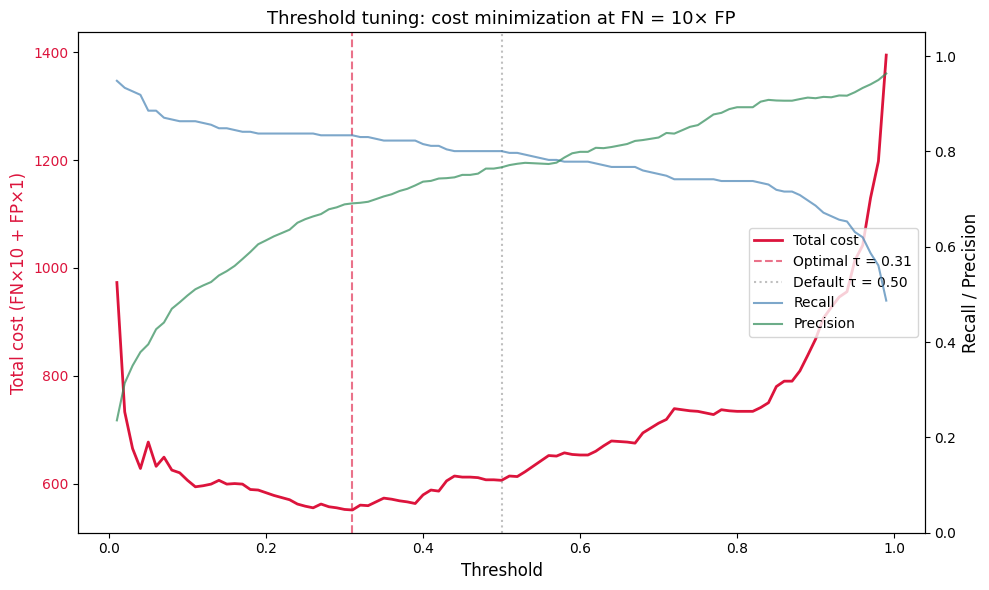

In [20]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Cost on left axis (red)
ax1.plot(results_df['threshold'], results_df['cost'], color='crimson', linewidth=2, label='Total cost')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Total cost (FN×10 + FP×1)', color='crimson', fontsize=12)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.axvline(best['threshold'], color='crimson', linestyle='--', alpha=0.6,
            label=f"Optimal τ = {best['threshold']:.2f}")
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default τ = 0.50')

# Precision/recall on right axis
ax2 = ax1.twinx()
ax2.plot(results_df['threshold'], results_df['recall'],    color='steelblue', alpha=0.7, label='Recall')
ax2.plot(results_df['threshold'], results_df['precision'], color='seagreen',  alpha=0.7, label='Precision')
ax2.set_ylabel('Recall / Precision', fontsize=12)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Threshold tuning: cost minimization at FN = 10× FP', fontsize=13)
plt.tight_layout()
plt.show()


## Step 3 — Threshold Tuning Interpretation

### Technical interpretation

The cost-minimizing threshold for XGBoost under the 10:1 cost asymmetry is **τ = 0.31**, well below the default 0.50. At this cutoff:

- Recall: **0.834** (vs 0.801 at default τ=0.50) — 9 additional failures caught
- Precision: **0.691** (vs 0.767 at default) — alarm reliability ~69%
- Confusion matrix at τ=0.31: TP 226, FN 45, FP 101, TN 7628
- Total cost: **551 units** (vs 606 at default) — a 9.1% reduction

The trade is straightforward: lowering the threshold catches 9 more failures (TP +9, FN −9) at the cost of 35 more false alarms (FP +35). Under the 10:1 cost ratio, that's 90 FN-cost-units saved against 35 FP-cost-units spent — net savings of 55 units. The room to make this trade exists *because* of XGBoost's strong ranking quality (CV PR-AUC 0.842 ± 0.034): the model's probabilities in the 0.3–0.5 range are largely correct, so dropping the cutoff captures real failures rather than noise. With LR's weaker ranking (PR-AUC 0.484), the same threshold drop would have surfaced too many false alarms to be worthwhile.

Threshold tuning was performed on **out-of-fold predictions** from cross-validation (`cross_val_predict` with the same `StratifiedKFold(5)` used in model selection), preserving the test set for Step 4 final evaluation.

### Business interpretation

The default 0.50 cutoff leaves cost savings on the table. By being slightly more eager to flag potential failures, the system captures more genuine failures while maintaining respectable alarm reliability — when this system raises an alarm, it's right about 69% of the time.

In plain operational terms: at τ=0.31, the system trades 35 additional truck rolls (false alarms) for 9 additional caught failures (prevented breakdowns) compared to the default. Whether that trade is worth making depends on the cost ratio — at 10:1 it's clearly worth it; at 3:1 the default cutoff is closer to optimal.

Crucially, this is a **policy lever, not a model retrain**. The same trained model can be deployed with different thresholds for different asset classes — a critical-path dozer might justify τ=0.20 (catch everything, accept more inspections), a low-stakes fleet pickup might use τ=0.50 (only alarm when very confident). One model, multiple operating points, calibrated per business context.

### Decisions

1. **Locked threshold for final evaluation: τ = 0.31.** This is the cutoff applied to the held-out test set in Step 4.
2. **Cost ratio of 10:1 is an industry-typical placeholder, not a derived value.** In production deployment, the ratio would be calibrated per asset class against actual repair costs, downtime impact, and downstream operational risk.
3. **Threshold tuned on out-of-fold predictions, not the test set.** This preserves test-set integrity — the test set is touched exactly once, in Step 4, at the locked threshold.
4. **Cost minimization, not F1 optimization.** F1 implicitly weights precision and recall equally; cost minimization makes the asymmetry explicit and tunable.


In [21]:
from sklearn.metrics import (
    confusion_matrix, average_precision_score, roc_auc_score,
    precision_score, recall_score
)

# Refit XGBoost on the FULL training set (CV uses 4/5 holds; final eval uses everything)
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)
xgb_final.fit(X_train, y_train)

# Predict on the sealed test set
y_test_proba = xgb_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= BEST_THRESHOLD).astype(int)

# Threshold-independent metrics (model ranking quality, no cutoff applied)
prauc_test  = average_precision_score(y_test, y_test_proba)
rocauc_test = roc_auc_score(y_test, y_test_proba)

# Threshold-dependent metrics (at τ = 0.31)
precision_test = precision_score(y_test, y_test_pred)
recall_test    = recall_score(y_test, y_test_pred)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

print("="*60)
print(f"FINAL TEST SET EVALUATION  (τ = {BEST_THRESHOLD:.2f})")
print("="*60)

print(f"\nTest set: {len(y_test)} rows, {(y_test==1).sum()} failures "
      f"({100*(y_test==1).mean():.1f}%)\n")

print("Threshold-independent (ranking quality):")
print(f"  PR-AUC:    {prauc_test:.3f}    (CV was 0.842 ± 0.034)")
print(f"  ROC-AUC:   {rocauc_test:.3f}")

print(f"\nThreshold-dependent (at τ = {BEST_THRESHOLD:.2f}):")
print(f"  Recall:    {recall_test:.3f}    (CV/OOF was 0.834)")
print(f"  Precision: {precision_test:.3f}    (CV/OOF was 0.691)")

print(f"\nConfusion matrix:")
print(f"                Predicted")
print(f"                Healthy   Failure")
print(f"  Actual Healthy {tn:5d}    {fp:5d}")
print(f"  Actual Failure {fn:5d}    {tp:5d}")

print(f"\nTotal cost on test set (10×FN + 1×FP): {10*fn + fp} units")
print(f"  - Missed failures (FN): {fn}")
print(f"  - False alarms   (FP): {fp}")
print(f"  - Caught failures (TP): {tp}")

FINAL TEST SET EVALUATION  (τ = 0.31)

Test set: 2000 rows, 68 failures (3.4%)

Threshold-independent (ranking quality):
  PR-AUC:    0.865    (CV was 0.842 ± 0.034)
  ROC-AUC:   0.972

Threshold-dependent (at τ = 0.31):
  Recall:    0.824    (CV/OOF was 0.834)
  Precision: 0.636    (CV/OOF was 0.691)

Confusion matrix:
                Predicted
                Healthy   Failure
  Actual Healthy  1900       32
  Actual Failure    12       56

Total cost on test set (10×FN + 1×FP): 152 units
  - Missed failures (FN): 12
  - False alarms   (FP): 32
  - Caught failures (TP): 56


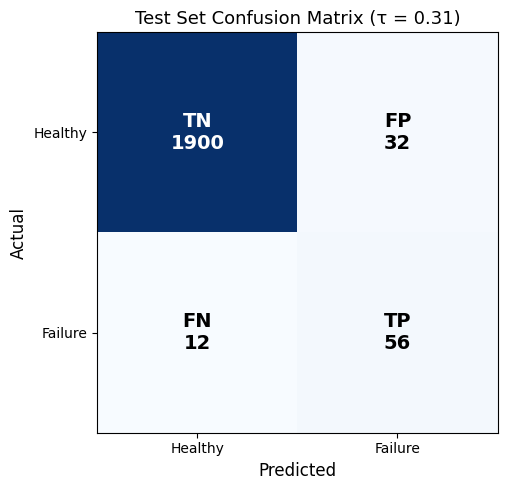

In [22]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Annotations
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                ha='center', va='center', color=text_color, fontsize=14, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Healthy', 'Failure'])
ax.set_yticklabels(['Healthy', 'Failure'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Test Set Confusion Matrix (τ = {BEST_THRESHOLD:.2f})', fontsize=13)
plt.tight_layout()
plt.show()

Feature importance (XGBoost gain-based):

              feature  importance       pct
 Rotational_speed_rpm    0.316593 31.659281
          power_proxy    0.194674 19.467390
        Tool_wear_min    0.159977 15.997688
            Torque_Nm    0.148802 14.880222
            temp_diff    0.054002  5.400231
               Type_M    0.040042  4.004164
Process_temperature_K    0.030996  3.099613
    Air_temperature_K    0.025532  2.553153
               Type_L    0.022129  2.212918
               Type_H    0.007253  0.725342

Engineered features (temp_diff, power_proxy) account for 24.9% of total importance.


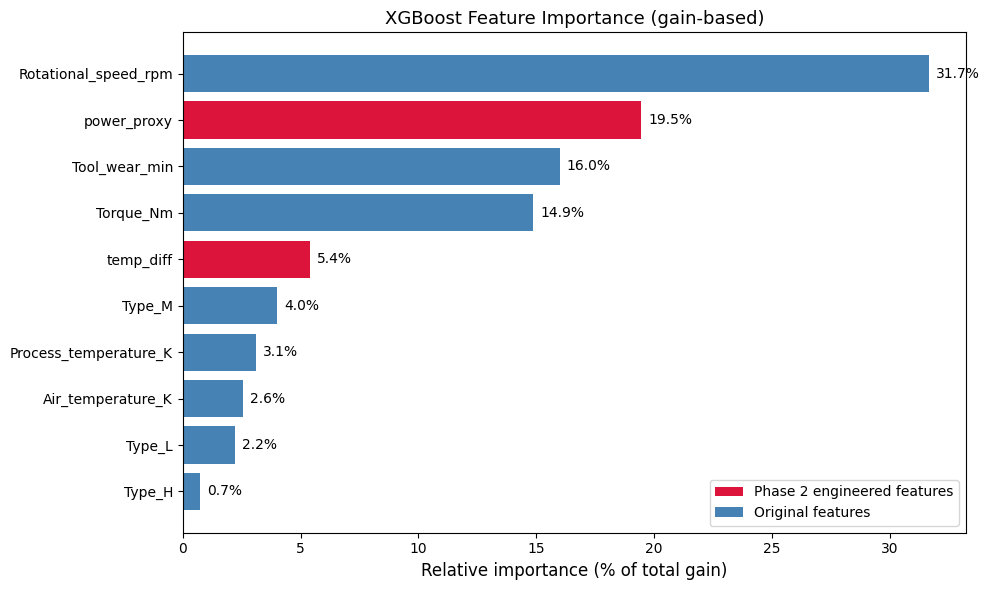

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Get importance scores aligned to feature names
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

# Convert to percentage of total
importance_df['pct'] = 100 * importance_df['importance'] / importance_df['importance'].sum()

print("Feature importance (XGBoost gain-based):\n")
print(importance_df.to_string(index=False))
print()

# Identify engineered features
engineered_features = {'temp_diff', 'power_proxy'}
engineered_total = importance_df[importance_df['feature'].isin(engineered_features)]['pct'].sum()
print(f"Engineered features ({', '.join(engineered_features)}) account for "
      f"{engineered_total:.1f}% of total importance.")

# Plot — sorted ascending so highest is at top of horizontal bars
plot_df = importance_df.sort_values('importance', ascending=True)
colors = ['crimson' if f in engineered_features else 'steelblue' for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['feature'], plot_df['pct'], color=colors)
ax.set_xlabel('Relative importance (% of total gain)', fontsize=12)
ax.set_title('XGBoost Feature Importance (gain-based)', fontsize=13)

# Value labels at end of bars
for i, val in enumerate(plot_df['pct']):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor='crimson', label='Phase 2 engineered features'),
    Patch(facecolor='steelblue', label='Original features'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## DS Deep Dive — Why XGBoost outperformed LR by 1.7×

The 1.7× PR-AUC gap between Logistic Regression (0.484) and XGBoost (0.842) was not an artifact of more parameters or more data. It was a structural difference in what each model can learn. This section reframes that gap through three lenses for different audiences.

### Plain English

Two ways a model can learn from data:

A linear model (LR) can only follow simple rules. It looks at each input, multiplies it by a fixed weight, and adds them up. If the answer is above some line, predict failure. The key word is *fixed* — the weight on torque is the same whether RPM is high or low. The model cannot say "torque matters more at high RPM" because that would require *changing* the weight depending on RPM. It cannot.

A tree-based model (XGBoost) can follow conditional rules. It builds decision trees: "if RPM > 2200, then check torque next; if RPM ≤ 2200, then check tool wear next." That branching structure means torque can matter differently depending on RPM, because they are checked in sequence at different parts of the tree. Trees can capture *interactions* — patterns where two things together mean something different than each one alone.

This is where feature engineering enters. When we computed power_proxy = torque × rpm, we calculated an interaction ourselves. For LR, that is a gift — it has done a calculation the model cannot do, and the model can use the result as if it were a simple input. That is why engineered features make a huge difference for LR.

For XGBoost, the interaction was *already discoverable* through tree branches. Giving it power_proxy still helps — a clean pre-computed signal it can split on directly, which makes the model converge faster and more accurately. But the *lift* from that engineered feature is smaller, because the tree could already approximate the interaction on its own.

**Takeaway:** feature engineering substitutes for a model's structural limitations. Simple models need a lot of it. Flexible models need less. The skill of a data scientist is knowing which model is being used and how much engineering effort to invest.

The bias-variance frame says the same thing more formally:

- Linear models have **high bias** — they assume reality is linear, so they have a ceiling on how well they can fit even with infinite data.
- Tree models have **lower bias** — they can fit non-linear shapes, so the ceiling is higher.
- Feature engineering raises the ceiling of linear models by injecting non-linearity manually. For tree models, the ceiling is already higher, so engineering raises it less.

### For non-DS stakeholders

When a manager or stakeholder asks "why are you spending time on feature engineering?", the answer is: **it depends on the model and the cost of getting it wrong.** Practical translations:

*Should we use a simpler model?* Simple models are easier to deploy, audit, and explain. But if the data has interactions — which most real-world operational data does — simple models will underperform unless significant DS effort goes into feature engineering. That is a budget question: pay upfront in engineering, or downstream in defending model complexity.

*How much DS time will the project need?* Planning depends on model choice. A simple-model project spends 60–70% of DS time on feature engineering and domain knowledge translation. A flexible-model project spends 30–40% on engineering and the rest on model selection, hyperparameter tuning, and explainability tooling.

*What does the accuracy gap between two models mean?* When one wins by a wide margin, the question is *why*. Here, XGBoost beat LR by 1.7×. The reason is not "more parameters always win" — it is that the data has multiplicative and conditional patterns the simple model structurally cannot represent. Even with feature engineering, LR cannot fully close the gap because we cannot pre-compute every possible interaction. Trees discover the ones we missed.

*Which model should we deploy?* This is a portfolio decision, not a binary one. Critical assets where a missed failure cascades into major business cost → flexible model, accept the explainability burden, invest in interpretability tooling. Lower-stakes assets where false alarms are cheap and explainability matters more → simpler model with engineered features, lighter deployment overhead.

### How this shows up in heavy equipment fleet operations

Heavy equipment failure is exactly the kind of problem where this distinction matters. Three concrete ways it shows up at work:

**1. Designing the predictive maintenance system.** A scraper's failure mode depends on multiple sensors interacting — hours × load × terrain grade, engine load × ambient temp × hydraulic temp, cycle time deviation × age × duty cycle severity. A simple model needs each of these computed manually — sit down with mechanics, derive formulas, validate against historical failures, ship them as features. Multiply by every equipment class and the feature engineering work alone is months. A flexible model can discover many of these interactions automatically given enough labeled failure events. The work shifts: less time engineering features, more time validating the model is not picking up spurious patterns and explaining decisions to project managers and equipment supers.

**2. Asset-class-by-asset-class deployment.** For dozer fleet on critical-path concrete pours, cost of a missed failure is enormous (50:1 or 100:1 vs false alarm), so a flexible model that catches more failures justifies the explainability work. Feature engineering still happens but mostly to provide *physically meaningful* signals (heat stress indices, duty cycle severity, cumulative load) the model can split on cleanly. For light-vehicle fleet where failures are inconvenient but not catastrophic, the cost ratio is closer to 3:1 or 5:1, a simpler model is easier to deploy across many low-stakes assets, and feature engineering does more of the heavy lifting because the model itself is doing less.

**3. Defending modeling choices to non-DS stakeholders.** Equipment supers and project managers are not data scientists. When they ask "why does the model think this dozer needs service?", an answer is needed. With a simple model the answer is straightforward: "the heat stress index is in the danger zone." With a flexible model the answer requires interpretability tooling: "the model identified this dozer's combination of hours, recent load profile, and ambient temperature pattern as matching a historical failure signature." The bias-variance and feature-engineering choice is not just a DS decision — it ripples into how the system is operated, audited, and trusted.

This is the nuance that separates a junior data scientist from a senior one. The junior runs the models and reports the metrics. The senior explains *why* the metrics came out the way they did, what it implies about the data, and how the choice of model shapes everything downstream — feature engineering effort, deployment complexity, stakeholder communication, and operational trust.

## Phase 3 Closeout — Modeling Summary

### What was built

A binary classifier predicting CNC milling machine failure from 7 sensor signals + 3 engineered features:

- **Logistic Regression baseline** with `class_weight='balanced'` and `StandardScaler`, evaluated by 5-fold stratified CV
- **XGBoost** with `scale_pos_weight=28.5` matched to the class imbalance, evaluated by the same CV protocol for apples-to-apples comparison
- **Cost-weighted threshold tuning** at 10:1 cost ratio (FN:FP), tuned on out-of-fold predictions to preserve test-set integrity
- **Final test evaluation** at the locked threshold τ=0.31 — the test set was touched exactly once

### Decision traceability matrix

| Modeling decision | Phase 1 finding that motivated it |
|---|---|
| Use **PR-AUC** instead of accuracy as the headline metric | 28:1 class imbalance (3.4% positive rate) makes accuracy misleading — a "predict healthy always" model achieves 96.6% accuracy |
| **Stratified** train/test split (80/20) | 28:1 imbalance — random split risks underrepresenting failure class in test set |
| **StratifiedKFold(5)** for cross-validation | Same imbalance — need consistent positive class proportion across folds for stable evaluation |
| `class_weight='balanced'` (LR) / `scale_pos_weight≈28.5` (XGBoost) | 28:1 imbalance requires loss-weighting to prevent the model from collapsing to majority-class predictions |
| **Drop 5 leakage columns** (TWF, HDF, PWF, OSF, RNF) | Discovered relationship: `Machine failure = OR(TWF, HDF, PWF, OSF, RNF)` holds for 99.73% of rows — these encode the label |
| Engineer **`temp_diff = process_temp − air_temp`** | Multicollinearity: process_temp ↔ air_temp at +0.88 — engineered feature isolates the heat-rise signal |
| Engineer **`power_proxy = torque × rpm × 2π/60`** | Multicollinearity: torque ↔ rpm at −0.88 — engineered feature captures the multiplicative mechanical-work signal |
| **One-hot encode Type** (keep all three indicators) | Type carries small but real signal: L 3.92% / M 2.77% / H 2.09% failure rates |
| **Cost-asymmetric threshold tuning** (10× FN:FP) | Cost asymmetry is structural to predictive maintenance — missed failures dominate false alarms in operational cost |
| **Tune threshold on OOF predictions**, not test set | Tuning on test would inflate final evaluation — OOF gives an honest pre-test estimate |

### Final results

| Metric | LR baseline (CV) | XGBoost (CV) | XGBoost (test) |
|---|---|---|---|
| PR-AUC | 0.484 ± 0.025 | 0.842 ± 0.034 | **0.865** |
| Recall (τ=0.31 / default 0.5 for LR) | 0.823 ± 0.048 | 0.834 (OOF) | **0.824** |
| Precision (τ=0.31 / default 0.5 for LR) | — | 0.691 (OOF) | **0.636** |
| ROC-AUC | — | — | 0.972 |

**Confusion matrix at τ=0.31 on the test set (n=2,000):**

|  | Predicted Healthy | Predicted Failure |
|---|---|---|
| Actual Healthy | 1,900 (TN) | 32 (FP) |
| Actual Failure | 12 (FN) | **56 (TP)** |

- 56 of 68 actual failures caught — **82% catch rate**
- 32 false alarms across 1,932 healthy machines — **1.7% false alarm rate**
- Total cost on test set: 152 units (12 × 10 + 32 × 1)

### Engineered feature validation

| Feature | Importance share (gain-based) |
|---|---|
| Rotational_speed_rpm | 31.7% |
| **power_proxy** *(engineered)* | **19.5%** |
| Tool_wear_min | 16.0% |
| Torque_Nm | 14.9% |
| **temp_diff** *(engineered)* | **5.4%** |
| Type_M | 4.0% |
| Process_temperature_K | 3.1% |
| Air_temperature_K | 2.6% |
| Type_L | 2.2% |
| Type_H | 0.7% |

Engineered features account for **24.9% of total feature importance**. `power_proxy` ranks second of ten features overall; `temp_diff` ranks fifth, ahead of both raw temperature inputs individually. The Phase 2 feature engineering decisions are validated in the model.

### What's defensible vs. what's an assumption

**Defensible (validated by data):**
- The 1.7× PR-AUC lift from XGBoost over LR — non-overlapping per-fold ranges, every XGBoost fold beat every LR fold
- The threshold of τ=0.31 minimizing total cost under a 10:1 ratio — derived analytically from OOF probabilities
- The model's generalization — test PR-AUC (0.865) inside the CV envelope (0.842 ± 0.034)
- The engineered features carrying real predictive weight — confirmed by gain-based importance

**Assumptions that would be calibrated in production:**
- The 10:1 cost ratio is an industry-typical placeholder. Real deployment would calibrate per asset class against actual repair costs, downtime impact, and downstream operational risk
- XGBoost hyperparameters were not tuned beyond reasonable defaults. Tuning is a follow-up that would refine — not redirect — the result
- Other model classes (LightGBM, calibrated LR, neural nets) were not tested. XGBoost was chosen as the workhorse for this scale and structure of tabular data; broader benchmarking would be a follow-up

### Carry forward to deployment considerations

The model in its current form is suitable for a controlled pilot deployment. Production hardening would require: per-asset-class threshold calibration against real cost ratios, monitoring for distribution drift in sensor data, retraining cadence based on accumulated failure events, and stakeholder-facing interpretability (SHAP plots, partial dependence) for individual prediction explanations.